# Tuning Reinvent for drug discovery.

In this notebook, various plots and analysis are used to illustrate the effect of various Reinvent parameters.

# Effect of transforms on data in Reinvent.

Reinvent has various transforms available for your data (or you can define your own) to re-train its RL. Sometimes you want to penalise high values, other times you want to preserve a range and penalise values outside that range, depending on the quantity.  

Either way, Reinvent's RL works best if you use transforms, rather than raw data otherwise it can add too much bias to the model training. It is also worth remembering that the Reinvent RL assumes that higher transformed values mean a more desirable outcome for the RL. So, depending on your model, it might be necessary to transform to reflect this.

The below should only be used as a guide - **these parameters should be benchmarked, refined and carefully set** as they can lead to undesirable outcomes if set blindly.

Imports

In [1]:
import pandas as pd
import os
from IPython.display import display
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from itertools import product

from rdkit import Chem
from rdkit.Chem.rdRGroupDecomposition import RGroupDecompose
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdDepictor import Compute2DCoords
from rdkit.Chem.TemplateAlign import AlignMolToTemplate2D

import useful_rdkit_utils as uru

Helper functions.

In [2]:
def reverse_sigmoid(x, high=1.0, low=0.0, k=10.0, x0=0.0):
    return low + (high - low) / (1 + np.exp(k * (x - x0)))

## Reverse sigmoid transform for hERG

In this case, we have a ML model that predicts activity against the hERG ion channel. A common threshold for activity is `10 uM` and, in this case, the model is a binary classifier and outputs 0/1  (0=inactive, 1=active). The model itself and code for specification, training, etc. can be found in my Github 
[comp_chem/ml/adme_models/herg](https://github.com/coreytaylorcompchem/comp_chem/tree/main/ml/adme_models/herg).

The `reverse_sigmoid` transform has a reasonably good use case for binary hERG activity. It works when you have a quantity where a high value is bad and you want to penalise values that breach or approach it quite sharply, but values significantly less than the defined threshold are largely unpenalised in the model. As Reinvent interprets high value = desirable and low value = undesirable, the reverse transform is necessary to allow for the fact that a model prediction of 1 = active against hERG is actually the **undesirable outcome** that we want to penalise in re-training the RL.

Scoring function and tranform for the hERG model as defined in the `.toml`.

```
[[stage.scoring.component]]
[stage.scoring.component.herg]
[[stage.scoring.component.herg.endpoint]]
name = "herg inactive"
weight = 0.5
transform.type = "reverse_sigmoid"
transform.high = 1.0
transform.low = 0.0
transform.k = 10.0
params.model_file = "/home/corey/Documents/comp_chem/ml/adme_models/herg/herg_gnn.pt"
```


The above is largely self-explanatory for this use case; the transform boundaries (`transform.high` and `transform.low`) reflect the goal of 0=inactive/good and 1=active/bad and the weight in the model depends on this goal (in this case, the file is for R-group enumeration).

The one parameter to really tune is the `transform.k`. How do we interpret and set this value? Here's some dummy data to illustrate the effect of the transform.

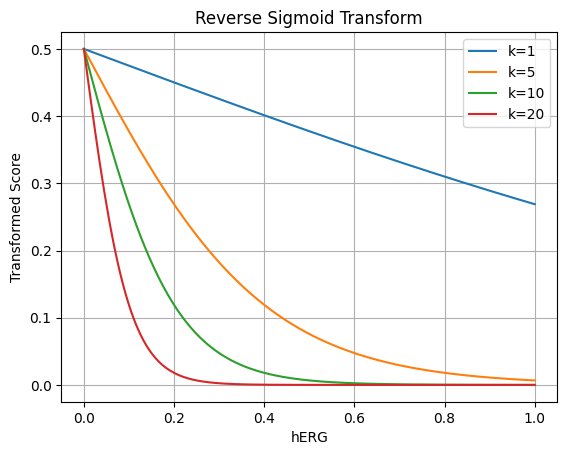

In [3]:
x_vals = np.linspace(0, 1, 200)
for k in [1, 5, 10, 20]:
    y_vals = reverse_sigmoid(x_vals, k=k, x0=0.0)
    plt.plot(x_vals, y_vals, label=f'k={k}')
    
plt.xlabel("hERG")
plt.ylabel("Transformed Score")
plt.title("Reverse Sigmoid Transform")
plt.legend()
plt.grid(True)
plt.show()


Clearly, at `k=10`, values from the model that approach the `transform.high` will be severely penalised. 

To illustrate, here are some examples from a real Reinvent output using `transform.k` = 10.

In [4]:
data_herg = {
  "SMILES": [
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(N4CCOCC4)cc3)c21', 
      'CC(NC(=O)c1cc(Cl)cc2ccn(C(=O)c3ccccc3)c12)c1ccc(C(F)(F)F)cc1', 
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(C4CC4)cc3)c21',
      'COc1cc(-c2ccc(C(C)NC(=O)c3cc(Cl)cc4ccn(C(C)=O)c34)cc2)ncc1C(F)(F)F', 
      ],
  "hERG_inactive_trans": [1.0, 0.0, 0.9988612, 0.005883],
  "hERG_inactive_raw": [0.2839, 0.8453, 0.4706, 0.5223]
}

df_herg = pd.DataFrame(data_herg)

In [5]:
rdkit_img = Draw.MolsToGridImage(
    mols=[Chem.MolFromSmiles(s) for s in list(df_herg.SMILES)],
    legends=[
        " ".join([" ", str(i)]) for i in zip(df_herg['hERG_inactive_trans'], df_herg['hERG_inactive_raw'])
    ],
    molsPerRow=3,
    maxMols=50,
)

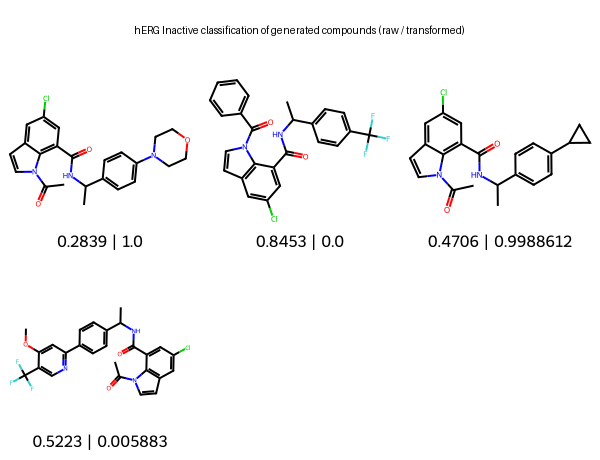

In [6]:
import io
from PIL import Image, ImageDraw, ImageFont
import math

mols_per_row = 3
sub_img_size = (200, 200)
title_height = 60
title_text = "hERG Inactive classification of generated compounds (raw / transformed)"

# Generate molecule images with legends.
mols = [Chem.MolFromSmiles(s) for s in df_herg.SMILES]
legends = [f"{i} | {j}" for i, j in zip(df_herg["hERG_inactive_raw"], df_herg["hERG_inactive_trans"])]
mol_imgs = [Draw.MolToImage(m, size=sub_img_size, legend=legends[i]) for i, m in enumerate(mols)]

# Annoyingly, MolsToGridImage doesn't natively support image titles, 
# so we need to do some manual reconstruction
n_mols = len(mol_imgs)
n_rows = math.ceil(n_mols / mols_per_row)
grid_width = mols_per_row * sub_img_size[0]
grid_height = n_rows * sub_img_size[1]

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, mol_img in enumerate(mol_imgs):
    row = idx // mols_per_row
    col = idx % mols_per_row
    x = col * sub_img_size[0]
    y = row * sub_img_size[1]
    grid_img.paste(mol_img, (x, y))

final_img = Image.new("RGB", (grid_img.width, grid_img.height + title_height), "white")

draw = ImageDraw.Draw(final_img)
try:
    font = ImageFont.truetype("arial.ttf", 32)
except:
    font = ImageFont.load_default()

bbox = draw.textbbox((0, 0), title_text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]
text_x = (grid_img.width - text_width) // 2
text_y = (title_height - text_height) // 2
draw.text((text_x, text_y), title_text, fill="black", font=font)

final_img.paste(grid_img, (0, title_height))
display(final_img)

We can clearly see from the first two examples which molecules will be signalled as desirable to the RL from the raw and transformed values. For the first molecule, the model predicted a low probability of hERG activity (**0.28**) so the transformed value becomes **1**, indicative of a desirable molecule to the Reinvent RL. The opposite is the case for the second molecule; a high probability (**0.85**) means a transform to **0**, signalling an undesirable molecule to Reinvent.

The last two examples show edge cases where probabilities from the model that are close (**0.48** vs **0.52**) are treated quite sharply by the transform (**0.99** vs **0.006**). This signals to the RL desirable and undesirable molecules, respectively. That they aren't straight-up assigned 1.0 and 0.0, however, shows there is some subtlety in the transform and the value that will be passed to the RL. Tuning `transform.k` will adjust this behaviour to make it more gradual. 

## Reverse sigmoid for CYP3A4 inhibition.

In this case, we have a ML model that predicts pIC50 against a Cytochrome P450 isoform (CYP3A4), a common toxity target in early drug discovery. The model itself and code for specification, training, etc. can be found in my Github 
[comp_chem/ml/adme_models/cyp_3a4](https://github.com/coreytaylorcompchem/comp_chem/tree/main/ml/adme_models/cyp_3a4).

The `reverse_sigmoid` transform again works well here but we set things up slightly different, as we are predicting pIC50 rather than a 0/1 binary outcome. As higher value = worse outcome, we still need to do the reverse transform for Reinvent. But here we set boundaries for an 'orange' zone of pIC50 5.0 - 7.0 i.e. molecules generated with a pIC50 in this range should be penalised, but not as harshly as those with a pIC50 > 7.0. 

Scoring function and tranform for the CYP3A4 model as defined in the `.toml`.

```
[[stage.scoring.component]]
[stage.scoring.component.cyp3a4pic50]
[[stage.scoring.component.cyp3a4pic50.endpoint]]
name = "CYP3A4 pIC50"
weight = 1.0
transform.type = "reverse_sigmoid"
transform.high = 7.0
transform.low = 5.0
transform.k = 2.0
params.model_file = "/home/corey/Documents/comp_chem/ml/adme_models/cyp_3a4/cyp_3a4_gin.pt"

```


The above is largely self-explanatory; the transform boundaries (`transform.high` and `transform.low`) reflect the 'orange' zone and those above and below that zone are penalised heavily and not penalised, respectively. The weight in the model depends on this goal, R-group enumeration in this case.

We have to be a little more careful with the `transform.k` here, as we may not want to set it as steeply given the 'orange zone' molecules. 

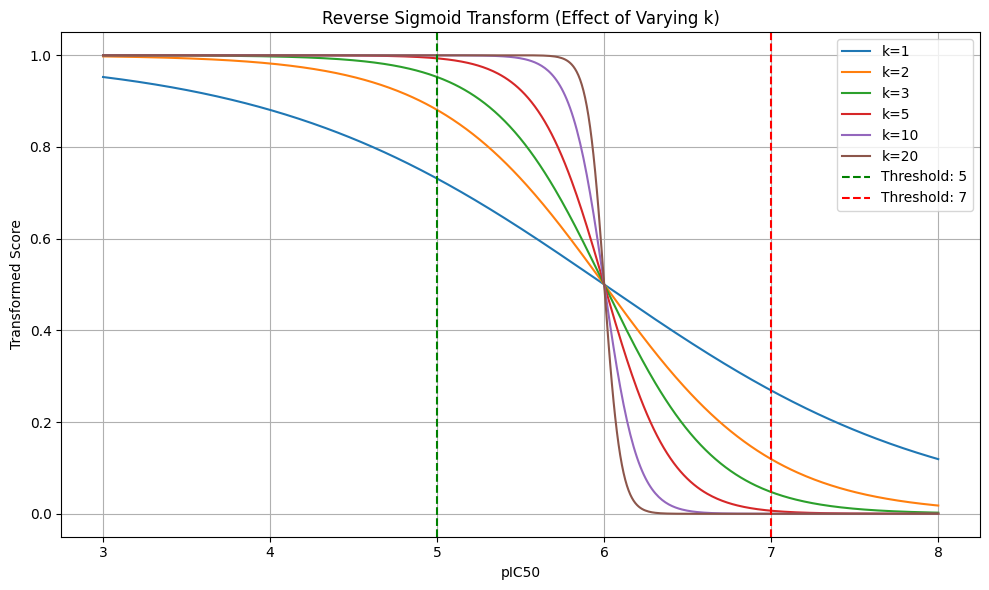

In [7]:
x_vals = np.linspace(3, 8, 500)
x0 = 6  # midpoint between "low" and "high" thresholds

plt.figure(figsize=(10, 6))
for k in [1, 2, 3, 5, 10, 20]:
    y_vals = reverse_sigmoid(x_vals, high=1.0, low=0.0, k=k, x0=x0)
    plt.plot(x_vals, y_vals, label=f'k={k}')

plt.axvline(5.0, color='green', linestyle='--', label='Threshold: 5')
plt.axvline(7.0, color='red', linestyle='--', label='Threshold: 7')

plt.xlabel("pIC50")
plt.ylabel("Transformed Score")
plt.title("Reverse Sigmoid Transform (Effect of Varying k)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


As said, we want to penalise 'orange' zone molecules a bit but not too much. Intuitively, `k=1` seems a bit too loose whilst `k=3` might be a bit steep. So we try `k=2` to ensure this balance. 

To illustrate, here are some examples from a real Reinvent output using `transform.k` = 2.

In [8]:
data_cyp = {
  "SMILES": [
      'Cc1ccc(C(C)NC(=O)c2cc(Cl)cc3ccn(C(=O)c4ccncc4Cl)c23)cc1',
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(C[n+]4cccnc4)cc3)c21',
      'CC(NC(=O)c1cc(Cl)cc2ccn(C(=O)CN(C)C)c12)c1ccc(-c2ccc(Cl)nc2)cc1',
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(Cn4cccn4)cc3)c21',
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(-c4cnn(C)c4)cc3)c21',
      ],
  "cyp_pic50_trans": [0.0000, 0.1954355, 0.4674587, 0.8659567, 0.9999972],
  "cyp_pic50_raw": [7.3616, 6.0615, 6.0057, 5.919, 5.445]
}

df_cyp = pd.DataFrame(data_cyp)

In [9]:
rdkit_img = Draw.MolsToGridImage(
    mols=[Chem.MolFromSmiles(s) for s in list(df_cyp.SMILES)],
    legends=[
        " ".join([" ", str(i)]) for i in zip(df_cyp['cyp_pic50_trans'], df_cyp['cyp_pic50_raw'])
    ],
    molsPerRow=3,
    maxMols=50,
)

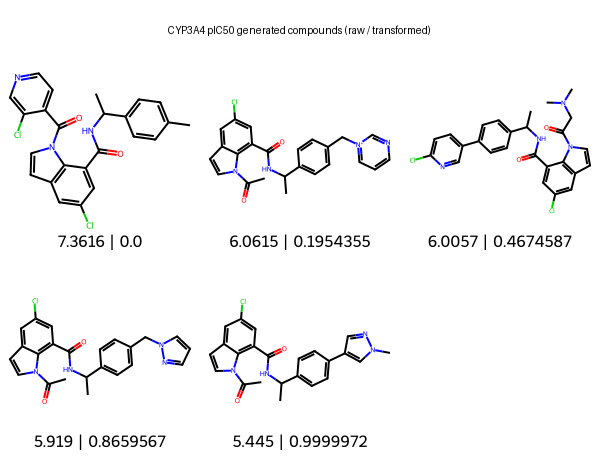

In [10]:
import io
from PIL import Image, ImageDraw, ImageFont
import math

mols_per_row = 3
sub_img_size = (200, 200)
title_height = 60
title_text = "CYP3A4 pIC50 generated compounds (raw / transformed)"

# Generate molecule images with legends.
mols = [Chem.MolFromSmiles(s) for s in df_cyp.SMILES]
legends = [f"{i} | {j}" for i, j in zip(df_cyp["cyp_pic50_raw"], df_cyp["cyp_pic50_trans"])]
mol_imgs = [Draw.MolToImage(m, size=sub_img_size, legend=legends[i]) for i, m in enumerate(mols)]

# Annoyingly, MolsToGridImage doesn't natively support image titles, 
# so we need to do some manual reconstruction
n_mols = len(mol_imgs)
n_rows = math.ceil(n_mols / mols_per_row)
grid_width = mols_per_row * sub_img_size[0]
grid_height = n_rows * sub_img_size[1]

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, mol_img in enumerate(mol_imgs):
    row = idx // mols_per_row
    col = idx % mols_per_row
    x = col * sub_img_size[0]
    y = row * sub_img_size[1]
    grid_img.paste(mol_img, (x, y))

final_img = Image.new("RGB", (grid_img.width, grid_img.height + title_height), "white")

draw = ImageDraw.Draw(final_img)
try:
    font = ImageFont.truetype("arial.ttf", 32)
except:
    font = ImageFont.load_default()

bbox = draw.textbbox((0, 0), title_text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]
text_x = (grid_img.width - text_width) // 2
text_y = (title_height - text_height) // 2
draw.text((text_x, text_y), title_text, fill="black", font=font)

final_img.paste(grid_img, (0, title_height))
display(final_img)

These molecules perhaps reflect classic med chem strategies to avoid inhibitiing this enzyme, demonstrate a neat evolution of generated molecules to minimise CYP inhibition and their effect on the Reinvent scoring function. Nicely, it also validates the predictive power of the model.

The first molecule has a predicted pIC50 of **~7.4** (~40 nM), the model heavily penalises it and it's not hard to see why. A classic CYP pharmacophore is a 'naked' pyridine, where the Nitrogen lone pairs are more free to coordinate to the Fe(III) in CYP's pocket. This molecule has a substituted pyridine but the meta positition of the halogen would do little to mitigate the basicity, and consequent availability, of the Nitrogen lone pair. Additionally, the amide linker is likely to add some flexibility which helps the rest of the molecule fit snugly into the hydrophoic parts of the CYP binding pocket. 

The next two molecules might as well be used as examples of what a med chemist would try to remove CYP toxicity at the indole. The second molecule is improved by substituting the pyridine with an N-acetylation on the indole and the second molecule does similar with a larger chain. Here the potency is worsened by > 1 log but is still a little high.  

Why might these be less desirable molecules to train our RL or, at least, be weighted lower? We still have potential CYP soft spots in molecule 2 and 3 with a pyrimidine and m-pyridine in the molecule, respectively. The second N of the pyrimidine would less basic but probably still haem-coordinating whilst the halogen in meta position of the latter molecule would likely reduce CYP binding but not by much.

The final two molecules have lower predicted pIC50s (**<6.0**) and this is likely reflected in their structure, where pyridines are omitted entirely. The pyrazole in the second-last molecule has a basic N but they are weak bases (pKa ~2.5). The final molecule adds a methyl and reduces flexibility by removing the linker, which should worsen its affinity for CYPs. Even if there is a clear ranking, both of these molecules should be weak CYP binders, hence the transform ensures that both will be considered favourable in the RL. 

## Double sigmoid transform for LogD

This time we have a model that predicts LogD. As the prediction is a continuous value, we use a regression model for it. The model itself and code for specification, training, etc. can be found in my Github 
[comp_chem/ml/adme_models/logd](https://github.com/coreytaylorcompchem/comp_chem/tree/main/ml/adme_models/logd).

The appropriate transform in this case is a `double_sigmoid` transform. Why? Because we want to define a resonable range of values for 'good' molecules to retrain the RL, as LogD has a upper and lower bound, then penalise any molecules that are outside these bounds, rather than only setting an upper limit as for hERG. The bounds I'll use here are **-1.0** to **3.5** for a 'good' LogD, but this is absolutely debatable.

Scoring function and tranform for the LogD model as defined in the `.toml`.

```
[[stage.scoring.component]]
[stage.scoring.component.logd]
[[stage.scoring.component.logd.endpoint]]
name = "LogD"
weight = 1.0
transform.type = "double_sigmoid"
transform.high = 3.5
transform.low = -1.0
transform.coef_div = 1.25
transform.coef_si = 5.0
transform.coef_se = 5.0
params.model_file = "/home/corey/Documents/comp_chem/ml/adme_models/logd/logd_gat.pt"
```


Again we define a `transform.high` and `transform.low` for R-group enumeration. However, the `transform.k` parameter we used with the hERG model isn't accepted by Reinvent for the `double_sigmoid` transform. We need to add three more parameters - `transform.coef_div`, `transform.coef_si` and `transform.coef_se`. These define the mid-point of the range as well as the slope of the curve on the left and right side, respectively.

Here's some dummy data to illustrate the effect of the transform I use above with the vertical line parameters indicating the 'good' LogD range (**-1.0** and **3.5**).

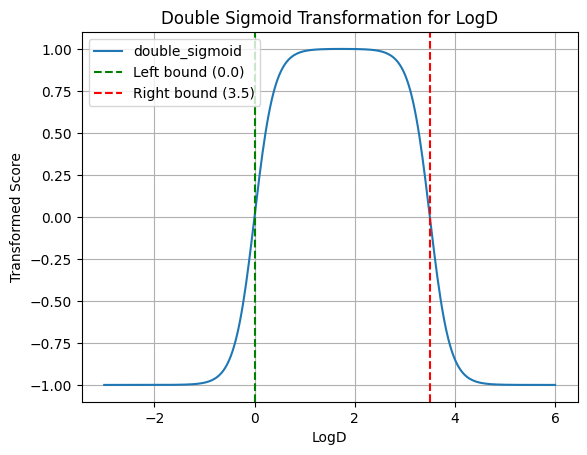

In [10]:
def double_sigmoid(x, low=-1.0, high=1.0, left_x=0.0, left_k=1.0, right_x=3.5, right_k=1.0):
    left = 1 / (1 + np.exp(-left_k * (x - left_x)))
    right = 1 / (1 + np.exp(right_k * (x - right_x)))
    return low + (high - low) * left * right

x_vals = np.linspace(-3, 6, 300)
y_vals = double_sigmoid(x_vals, left_x=0.0, left_k=5.0, right_x=3.5, right_k=5.0)

plt.plot(x_vals, y_vals, label="double_sigmoid")
plt.axvline(0.0, color='green', linestyle='--', label='Left bound (0.0)')
plt.axvline(3.5, color='red', linestyle='--', label='Right bound (3.5)')
plt.xlabel("LogD")
plt.ylabel("Transformed Score")
plt.title("Double Sigmoid Transformation for LogD")
plt.legend()
plt.grid(True)
plt.show()


So what happens when you vary other parameters?

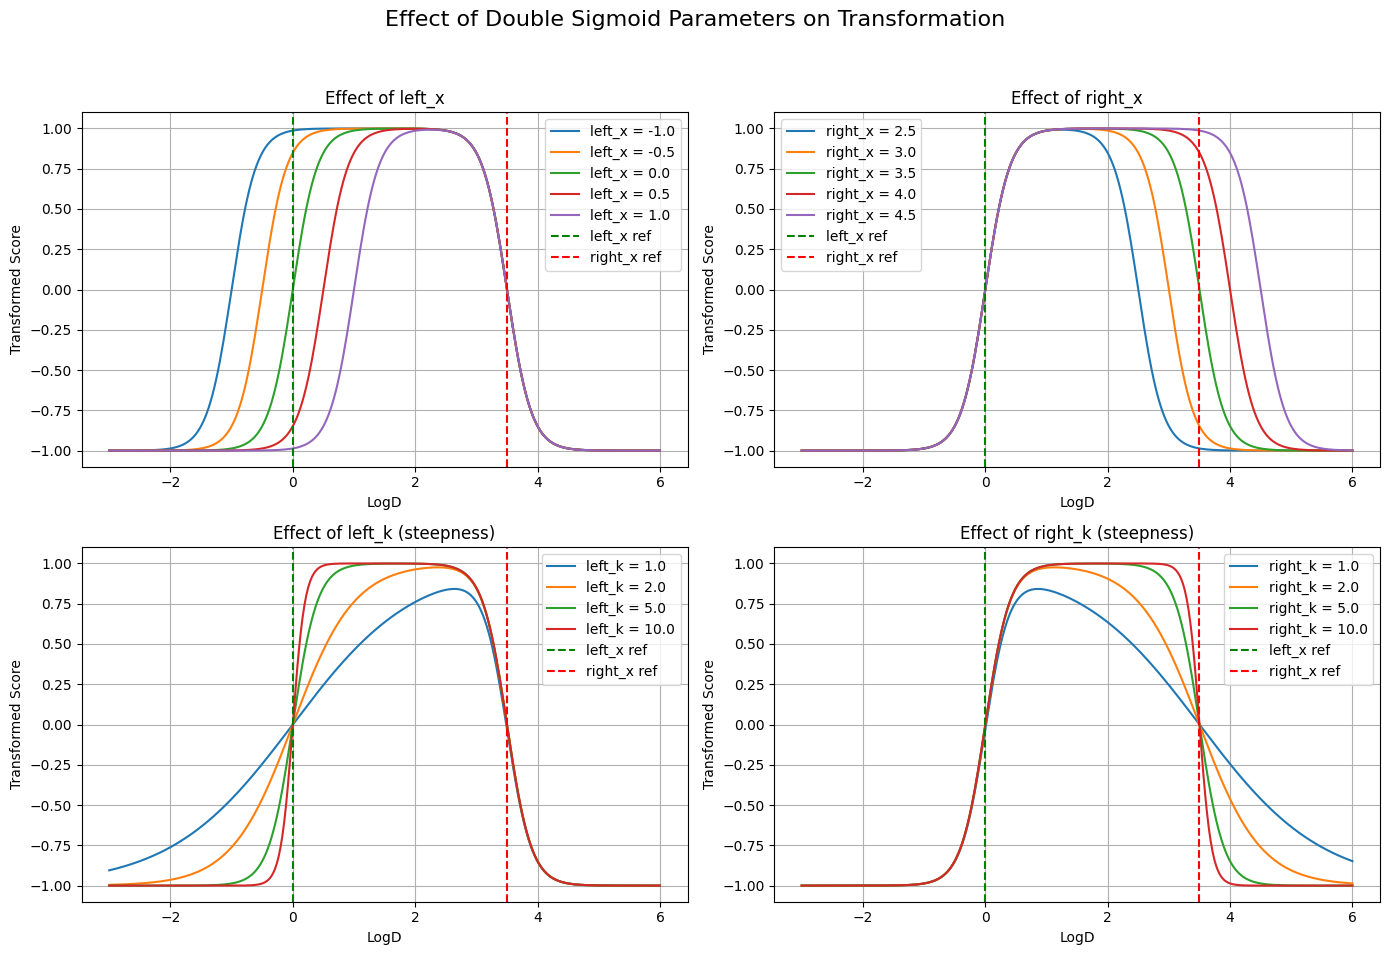

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def double_sigmoid(x, low=-1.0, high=1.0, left_x=0.0, left_k=1.0, right_x=3.5, right_k=1.0):
    left = 1 / (1 + np.exp(-left_k * (x - left_x)))
    right = 1 / (1 + np.exp(right_k * (x - right_x)))
    return low + (high - low) * left * right

x_vals = np.linspace(-3, 6, 300)

left_x_vals = [-1.0, -0.5, 0.0, 0.5, 1.0]
right_x_vals = [2.5, 3.0, 3.5, 4.0, 4.5]
left_k_vals = [1.0, 2.0, 5.0, 10.0]
right_k_vals = [1.0, 2.0, 5.0, 10.0]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Effect of Double Sigmoid Parameters on Transformation", fontsize=16)

# Default reference lines
default_left_x = 0.0
default_right_x = 3.5

# Varying left_x and right_x
for val in left_x_vals:
    y = double_sigmoid(x_vals, left_x=val, left_k=5.0, right_x=3.5, right_k=5.0)
    axs[0, 0].plot(x_vals, y, label=f"left_x = {val}")
axs[0, 0].axvline(default_left_x, color='green', linestyle='--', label='left_x ref')
axs[0, 0].axvline(default_right_x, color='red', linestyle='--', label='right_x ref')
axs[0, 0].set_title("Effect of left_x")
axs[0, 0].legend()
axs[0, 0].grid(True)

for val in right_x_vals:
    y = double_sigmoid(x_vals, left_x=0.0, left_k=5.0, right_x=val, right_k=5.0)
    axs[0, 1].plot(x_vals, y, label=f"right_x = {val}")
axs[0, 1].axvline(default_left_x, color='green', linestyle='--', label='left_x ref')
axs[0, 1].axvline(default_right_x, color='red', linestyle='--', label='right_x ref')
axs[0, 1].set_title("Effect of right_x")
axs[0, 1].legend()
axs[0, 1].grid(True)

# Varying left_k and right_k
for val in left_k_vals:
    y = double_sigmoid(x_vals, left_x=0.0, left_k=val, right_x=3.5, right_k=5.0)
    axs[1, 0].plot(x_vals, y, label=f"left_k = {val}")
axs[1, 0].axvline(default_left_x, color='green', linestyle='--', label='left_x ref')
axs[1, 0].axvline(default_right_x, color='red', linestyle='--', label='right_x ref')
axs[1, 0].set_title("Effect of left_k (steepness)")
axs[1, 0].legend()
axs[1, 0].grid(True)

for val in right_k_vals:
    y = double_sigmoid(x_vals, left_x=0.0, left_k=5.0, right_x=3.5, right_k=val)
    axs[1, 1].plot(x_vals, y, label=f"right_k = {val}")
axs[1, 1].axvline(default_left_x, color='green', linestyle='--', label='left_x ref')
axs[1, 1].axvline(default_right_x, color='red', linestyle='--', label='right_x ref')
axs[1, 1].set_title("Effect of right_k (steepness)")
axs[1, 1].legend()
axs[1, 1].grid(True)

for ax in axs.flat:
    ax.set_xlabel("LogD")
    ax.set_ylabel("Transformed Score")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


So, in general we see that broadening the curve via `left_x` and `right_x` will govern your acceptable range of LogDs. This should probably be expert-driven. Varying the steepness via `left_k` and `right_k` is probably more fruitful to toy with for Reinvent, as it introduces subtlety in which molecules will influence the Reinvent RL.

Depending on the parameters, molecules outside of the -1.0/3.5 LogD can be strictly penalised if you want. This should be appropriately harsh for lead opt and R-group enumerations but you might loosen that criteria for genuine denovo generation when you want to explore a bit. 

To illustrate, here are some examples from a real Reinvent output with the LogD prediction, before and after transform.

In [12]:
data_logd = {
  "SMILES": [
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(Cn4cc(C)c(=O)[nH]c4=O)cc3)c21',
      'CNS(=O)(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(N4CCOCC4)cc3)c21',
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(-c4ccno4)cc3)c21',
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(C(F)(F)F)cc3)c21',
      'CC(NC(=O)c1cc(Cl)cc2ccn(C(=O)NC(C)c3ccc(Br)cc3)c12)c1ccc(C(F)(F)F)cc1'
      ],
  "LogD_trans": [0.99999, 0.9507052, 0.48344, 0.00036, 0.0000008],
  "LogD_raw": [2.6529, 3.1787, 3.5072, 4.3613, 5.0209]
}

df_logd = pd.DataFrame(data_logd)

In [13]:
rdkit_img = Draw.MolsToGridImage(
    mols=[Chem.MolFromSmiles(s) for s in list(df_logd.SMILES)],
    legends=[
        " ".join([" ", str(i)]) for i in zip(df_logd['LogD_trans'], df_logd['LogD_raw'])
    ],
    molsPerRow=3,
    maxMols=50,
)

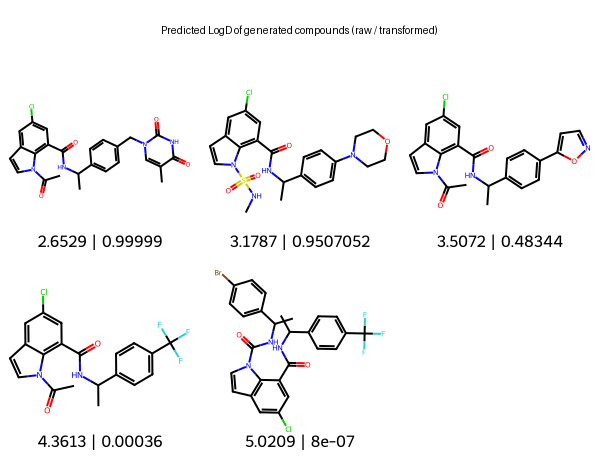

In [14]:
import io
from PIL import Image, ImageDraw, ImageFont
import math

mols_per_row = 3
sub_img_size = (200, 200)
title_height = 60
title_text = "Predicted LogD of generated compounds (raw / transformed)"

# Generate molecule images with legends.
mols = [Chem.MolFromSmiles(s) for s in df_logd.SMILES]
legends = [f"{i} | {j}" for i, j in zip(df_logd["LogD_raw"], df_logd["LogD_trans"])]
mol_imgs = [Draw.MolToImage(m, size=sub_img_size, legend=legends[i]) for i, m in enumerate(mols)]

# Annoyingly, MolsToGridImage doesn't natively support image titles, 
# so we need to do some manual reconstruction
n_mols = len(mol_imgs)
n_rows = math.ceil(n_mols / mols_per_row)
grid_width = mols_per_row * sub_img_size[0]
grid_height = n_rows * sub_img_size[1]

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, mol_img in enumerate(mol_imgs):
    row = idx // mols_per_row
    col = idx % mols_per_row
    x = col * sub_img_size[0]
    y = row * sub_img_size[1]
    grid_img.paste(mol_img, (x, y))

final_img = Image.new("RGB", (grid_img.width, grid_img.height + title_height), "white")

draw = ImageDraw.Draw(final_img)
try:
    font = ImageFont.truetype("arial.ttf", 32)
except:
    font = ImageFont.load_default()

bbox = draw.textbbox((0, 0), title_text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]
text_x = (grid_img.width - text_width) // 2
text_y = (title_height - text_height) // 2
draw.text((text_x, text_y), title_text, fill="black", font=font)

final_img.paste(grid_img, (0, title_height))
display(final_img)

The range of predicted LogD shows how harshly the transform penalises molecules approaching the upper limit of 'good' LogD of **3.5**. The first molecules have predicted LogDs of **2.7** and **3.2**, respectively, so are assigned high desirabilities close to 1.0. As we breach the threshold, even a little, the penalisation begins until molecules that have a predicted LogD > 4.0 eventually have little/no impact on the model. Again, as we're doing R-group enumeration, we're trying to be strict. In other projects, this can of course be adjusted.